In [17]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from PIL import Image

imageSet = 's11'

In [18]:
# Load all the images of specific set
def load_images(path):
    images = []
    for file in os.listdir(path):
        img = Image.open(os.path.join(path, file)).convert('L')  #L -Luinance(balck and white)
        images.append(np.array(img)) # Converting images to 2d array 
    return np.array(images)

In [19]:
faces = load_images('./Data/Dataset/att_faces/'+imageSet)
print("Dataset shape:", faces.shape)
print(f'face = {faces}')

Dataset shape: (10, 112, 92)
face = [[[ 48  46  49 ...  37  39  40]
  [ 43  53  46 ...  36  40  41]
  [ 52  43  53 ...  40  39  41]
  ...
  [ 62  48  49 ...  30  33  32]
  [ 56  25  92 ...  32  31  30]
  [ 43 110 215 ...  31  31  36]]

 [[ 50  46  49 ...  43  41  36]
  [ 46  48  52 ...  38  44  43]
  [ 48  49  53 ...  37  45  38]
  ...
  [ 62 170 224 ...  38  34  37]
  [211 214 222 ...  31  33  32]
  [210 210 218 ...  33  33  41]]

 [[ 45  49  47 ...  40  39  42]
  [ 46  51  50 ...  41  39  37]
  [ 48  48  51 ...  41  38  38]
  ...
  [ 53  62  59 ...  36  33  36]
  [ 56  56  54 ...  37  39  36]
  [ 67  84  88 ...  40  30  44]]

 ...

 [[ 52  48  47 ...  40  40  41]
  [ 51  45  54 ...  44  39  48]
  [ 52  48  48 ...  42  43  38]
  ...
  [ 62  60  57 ...  29  31  30]
  [ 60  56  56 ...  32  28  35]
  [ 59  71  61 ...  32  31  37]]

 [[ 44  48  45 ...  39  40  40]
  [ 47  49  46 ...  40  42  38]
  [ 44  47  51 ...  39  42  41]
  ...
  [ 51  58  52 ...  36  30  39]
  [ 54  49  56 ...  32  

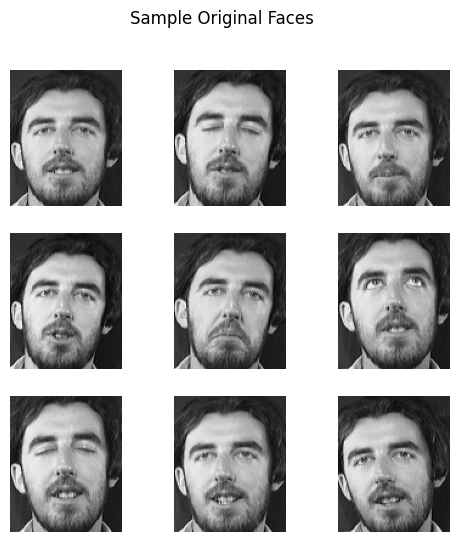

In [20]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(faces[i], cmap='gray')
    plt.axis('off')
plt.suptitle('Sample Original Faces')
plt.show()

In [21]:
#  Converting images into vectors 
# X - row : Each data/image, 
# X - col : different pixel values of subject in different data
n_samples, h, w = faces.shape
X = faces.reshape(n_samples, h * w)
print("Data matrix shape:", X.shape)

Data matrix shape: (10, 10304)


In [22]:
# PCA - Mean centering
mean_face = np.mean(X, axis = 0)    # axis = 0 -> operate coloumn-wise : take the mean of each pixel across all images
X_centered = X - mean_face          # Determine deviance of each pixel value from the mean (Eg: 133 - 129.3 = 3.7)
# print(f'Mean face = {mean_face}')
# print(f'X = {X}')
# print(f'X_centered = {X_centered}')

In [23]:
# Applying SVD 
    # Vt = eigenfaces
    # S = singular values
    # Eigenvalues = S^2/(n-1)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# print(f'U = {U}')
# print(f'S = {S}')
# print(f'Vt = {Vt}')

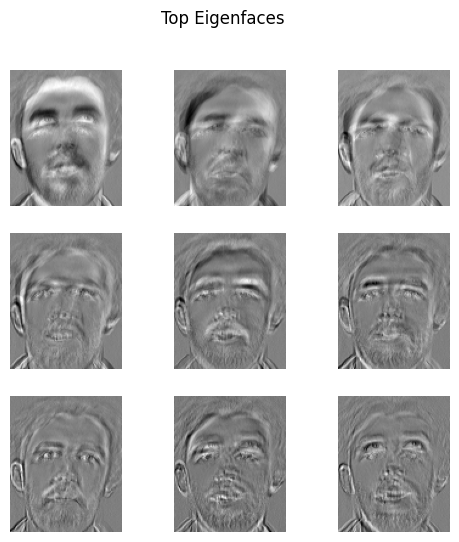

In [24]:
# Visualize eigenfaces
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(Vt[i].reshape(h, w), cmap='gray')
    plt.axis('off')
plt.suptitle("Top Eigenfaces")
plt.show()

In [25]:
# Reconstruction function the face

def reconstruct_image(x, mean, Vt, k):
    return mean + x @ Vt[:k].T @ Vt[:k]


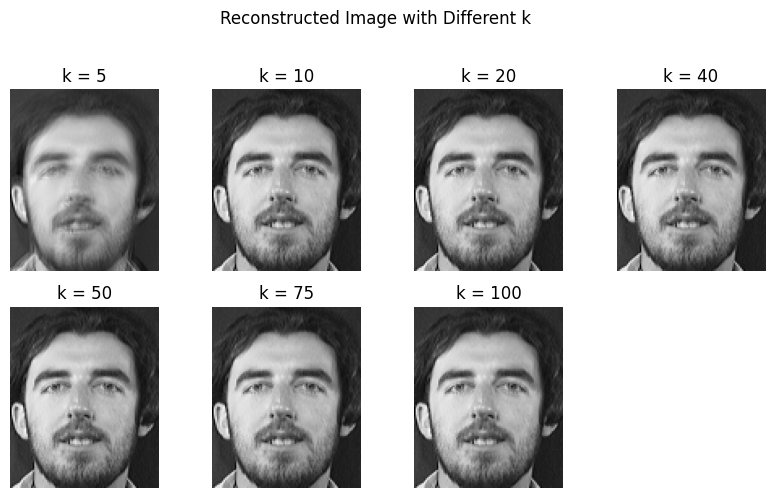

In [26]:
# Comparing the different k values 
k_values = [5, 10, 20, 40, 50, 75, 100]

img_index = 0
plt.figure(figsize=(10,8))

for i, k in enumerate(k_values):
    recon = reconstruct_image(X_centered[img_index], mean_face, Vt, k)
    plt.subplot(3,4,i+1)
    plt.imshow(recon.reshape(h,w), cmap='gray')
    plt.title(f"k = {k}")
    plt.axis('off')

plt.suptitle("Reconstructed Image with Different k")
plt.show()


# Analysis
<ol>
    <li> Compression Ratio 
        <ul>
            <li> Defined by :
                Compression Ratio= Compressed storage / Original storage​
            <li> Higher ration -> better compression
            <li> Trade-off with image quality 
        </ul>
    <li> Mean Squared Error (MSE)
        <ul>
            <li> Measures how much information is lost during reconstruction
            <li> Lower MSE → better reconstruction
            <li> MSE decreases as k increases
        </ul>
</ol>




In [27]:
# Function to compute MSE and Compression ratio
data = faces.shape
N = data[1]
d = data[2]

def compute_mse(original, reconstruct_image):
    return np.mean((original - reconstruct_image)**2)

def compute_compression_ratio(k):
    original_size = N*d
    compressed_size = k*(N+d+1)
    return original_size / compressed_size

In [28]:
def pca_reconstruct(U, S, Vt, mean_image, k):
    """
    Reconstructs image using first k PCA components.
    """
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vk = Vt[:k, :]

    X_reconstructed = Uk @ Sk @ Vk + mean_image
    return X_reconstructed

In [29]:
# Compute metric for different k
mse_values = [] 
compression_ratios = []
X_Original = X

for k in k_values:
    recon = pca_reconstruct(U, S, Vt, mean_face, k)
    mse = compute_mse(X_Original, recon)
    cr = compute_compression_ratio(k)

    mse_values.append(mse)
    compression_ratios.append(cr)

print(f'Mse Values are: {mse_values}')
print(f'Compress ratios = {compression_ratios}')

Mse Values are: [np.float64(143.53199493974267), np.float64(6.277284921424361e-27), np.float64(6.277284921424361e-27), np.float64(6.277284921424361e-27), np.float64(6.277284921424361e-27), np.float64(6.277284921424361e-27), np.float64(6.277284921424361e-27)]
Compress ratios = [10.052682926829268, 5.026341463414634, 2.513170731707317, 1.2565853658536585, 1.0052682926829268, 0.6701788617886179, 0.5026341463414634]


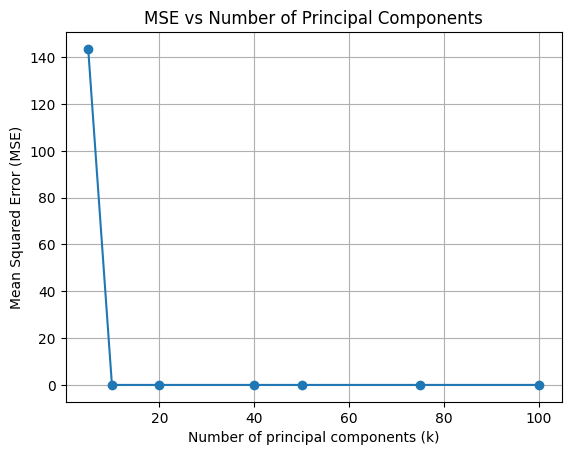

In [30]:
# MSE Vs Number of Components k

plt.figure()
plt.plot(k_values, mse_values, marker='o')
plt.xlabel("Number of principal components (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE vs Number of Principal Components")
plt.grid(True)
plt.show()


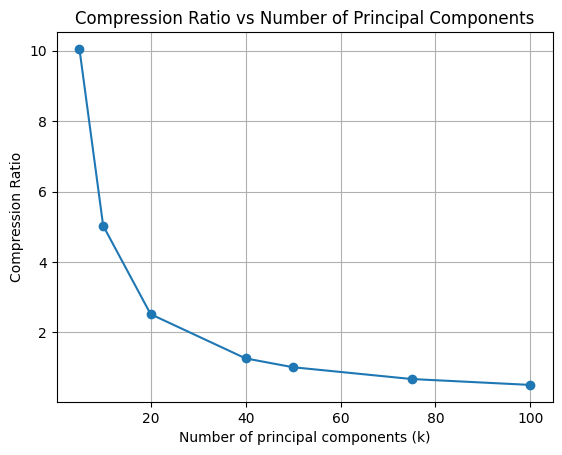

In [31]:
# Compression Ratio vs Number of Components 𝑘
plt.figure()
plt.plot(k_values, compression_ratios, marker='o')
plt.xlabel("Number of principal components (k)")
plt.ylabel("Compression Ratio")
plt.title("Compression Ratio vs Number of Principal Components")
plt.grid(True)
plt.show()
